# Calculadora de Ancestralidade Genômica — guia executável

Notebook completo para executar o projeto no Google Colab, seguindo o enunciado fornecido.

**Atenção:** o PDF não informa os nomes exatos das colunas de população no `.psam`, nem se `INDEX` do `harmonization_map.csv` é 0-based ou 1-based. O código tenta detectar ambos os casos e para com uma mensagem clara quando não for possível. O QC também não tem limiares numéricos definidos no PDF; por padrão, o notebook não inventa MAF/call-rate mínimo.

Este bloco de código instala as bibliotecas `pgenlib` e `zstandard`, que são essenciais para manipular arquivos genômicos no formato PGEN e para lidar com a compressão Zstandard.

In [57]:
!pip -q install pgenlib zstandard

Este bloco de código monta o Google Drive no ambiente Colab, permitindo o acesso aos arquivos de dados. Em seguida, define os caminhos para os arquivos de entrada necessários (`genotipo_microarray.csv`, `1000G_GSA_SNP.pgen`, `1000G_GSA_SNP.pvar.zst`, `1000G_GSA_SNP.psam`, `harmonization_map.csv`) e verifica se todos existem, levantando um erro caso algum esteja faltando.

In [43]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')

BASE = Path('/content/drive/MyDrive/Aprendizado em genômica/Projeto_Ancestralidade')
INDIVIDUO = BASE/'individuo'
PROCESSED = BASE/'processed'
GENOTIPO = INDIVIDUO/'genotipo_microarray.csv'
PGEN = PROCESSED/'1000G_GSA_SNP.pgen'
PVAR = PROCESSED/'1000G_GSA_SNP.pvar.zst'
PSAM = PROCESSED/'1000G_GSA_SNP.psam'
HARMONIZATION = PROCESSED/'harmonization_map.csv'

for f in [GENOTIPO,PGEN,PVAR,PSAM,HARMONIZATION]:
    print(('✓' if f.exists() else '✗'), f)
    if not f.exists(): raise FileNotFoundError(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ /content/drive/MyDrive/Aprendizado em genômica/Projeto_Ancestralidade/individuo/genotipo_microarray.csv
✓ /content/drive/MyDrive/Aprendizado em genômica/Projeto_Ancestralidade/processed/1000G_GSA_SNP.pgen
✓ /content/drive/MyDrive/Aprendizado em genômica/Projeto_Ancestralidade/processed/1000G_GSA_SNP.pvar.zst
✓ /content/drive/MyDrive/Aprendizado em genômica/Projeto_Ancestralidade/processed/1000G_GSA_SNP.psam
✓ /content/drive/MyDrive/Aprendizado em genômica/Projeto_Ancestralidade/processed/harmonization_map.csv


Este bloco importa as bibliotecas Python necessárias para a análise genômica, como `numpy` para operações numéricas, `pandas` para manipulação de dados, `matplotlib` e `seaborn` para visualização, `zstandard` para descompressão, `pgenlib` para leitura de arquivos PGEN e `sklearn` para aprendizado de máquina (PCA, k-NN). Também define funções auxiliares para normalização de colunas, busca de colunas, tratamento de valores booleanos, limpeza e codificação de genótipos, complementação de alelos e leitura de arquivos `.pvar` comprimidos. Por fim, define uma função para imputar valores ausentes em matrizes e vetores genéticos.

In [58]:
import io, re, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zstandard as zstd
import pgenlib
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.optimize import minimize

RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

pop_to_super={
'ACB':'AFR','ASW':'AFR','ESN':'AFR','GWD':'AFR','LWK':'AFR','MSL':'AFR','YRI':'AFR',
'CLM':'AMR','MXL':'AMR','PEL':'AMR','PUR':'AMR',
'CDX':'EAS','CHB':'EAS','CHS':'EAS','JPT':'EAS','KHV':'EAS',
'CEU':'EUR','FIN':'EUR','GBR':'EUR','IBS':'EUR','TSI':'EUR',
'BEB':'SAS','GIH':'SAS','ITU':'SAS','PJL':'SAS','STU':'SAS'}

def normcol(c): return re.sub(r'[^a-z0-9]','',str(c).lower().replace('#',''))
def findcol(df,cands,required=True):
    m={normcol(c):c for c in df.columns}
    for x in cands:
        if normcol(x) in m: return m[normcol(x)]
    if required: raise ValueError(f'Coluna não encontrada. Candidatas={cands}; disponíveis={list(df.columns)}')
    return None
#def as_bool(v): return False if pd.isna(v) else str(v).strip().lower() in {'1','true','t','yes','y','sim','s'}
def clean_gt(v):
    if pd.isna(v): return None
    s=re.sub(r'[/|\s]','',str(v).upper().strip())
    return None if s in {'','-','--','00','NN','NC','N/A','NA','NAN'} else s
#def complement(s): return s.translate(str.maketrans({'A':'T','T':'A','C':'G','G':'C'}))
def encode_gt(gt,ref,alt):
    gt=clean_gt(gt); ref=str(ref).upper().strip(); alt=str(alt).upper().strip()
    if gt is None or len(gt)!=2 or len(ref)!=1 or len(alt)!=1: return -9
    a,b=gt
    if a==ref and b==ref: return 0
    if (a==ref and b==alt) or (a==alt and b==ref): return 1
    if a==alt and b==alt: return 2
    return -9
def read_pvar(path):
    path=Path(path)
    if path.suffix=='.zst':
        with open(path,'rb') as fh:
            with zstd.ZstdDecompressor().stream_reader(fh) as rr:
                txt=io.TextIOWrapper(rr)
                for line in txt:
                    if line.startswith('##'): continue
                    header=line.rstrip('\n').split('\t'); break
                return pd.read_csv(txt,sep='\t',names=header,dtype=str)
    with open(path,'rt') as txt:
        for line in txt:
            if line.startswith('##'): continue
            header=line.rstrip('\n').split('\t'); break
        return pd.read_csv(txt,sep='\t',names=header,dtype=str)
def impute_matrix(Xi,means):
    X=Xi.astype(np.float32,copy=True); r,c=np.where(X<0)
    if len(r): X[r,c]=means[c]
    return X
def impute_vector(xi,means):
    x=xi.astype(np.float32,copy=True); m=x<0; x[m]=means[m]; return x

Este bloco lê os arquivos `PSAM` (informações de amostra) e `PVAR` (informações de variante) e inicializa o leitor de arquivos PGEN. Ele verifica se o número de indivíduos e variantes corresponde entre os arquivos e mapeia as populações para superpopulações. O bloco também garante que todas as populações tenham um mapeamento de superpopulação.

In [59]:
metadata_raw=pd.read_csv(PSAM,sep=r'\s+',dtype=str)
pvar=read_pvar(PVAR)
pgen=pgenlib.PgenReader(str(PGEN).encode())
N=pgen.get_raw_sample_ct(); V=pgen.get_variant_ct()
print('PGEN:',N,'indivíduos;',V,'variantes')
print('PSAM:',list(metadata_raw.columns))
print('PVAR:',list(pvar.columns))
assert len(metadata_raw)==N and len(pvar)==V

SAMPLE_COL=findcol(metadata_raw,['#IID','IID','sample','sample_id','id'])
POP_COL=findcol(metadata_raw,['population','pop','population_code','pop_code'])
SUPER_COL=findcol(metadata_raw,['superpopulation','super_pop','superpop','superpopulation_code','super_pop_code'],False)
metadata=pd.DataFrame({'sample':metadata_raw[SAMPLE_COL].astype(str),'population':metadata_raw[POP_COL].astype(str).str.upper()})
metadata['superpopulation']=metadata_raw[SUPER_COL].astype(str).str.upper() if SUPER_COL else metadata['population'].map(pop_to_super)
if metadata['superpopulation'].isna().any(): raise ValueError('Há populações sem superpopulação mapeada.')
print(metadata.head()); print('Populações:',sorted(metadata.population.unique()))

PGEN: 3202 indivíduos; 575480 variantes
PSAM: ['#IID', 'PAT', 'MAT', 'SEX', 'SuperPop', 'Population']
PVAR: ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'INFO']
    sample population superpopulation
0  HG00096        GBR             EUR
1  HG00097        GBR             EUR
2  HG00099        GBR             EUR
3  HG00100        GBR             EUR
4  HG00101        GBR             EUR
Populações: ['ACB', 'ASW', 'BEB', 'CDX', 'CEU', 'CHB', 'CHS', 'CLM', 'ESN', 'FIN', 'GBR', 'GIH', 'GWD', 'IBS', 'ITU', 'JPT', 'KHV', 'LWK', 'MSL', 'MXL', 'PEL', 'PJL', 'PUR', 'STU', 'TSI', 'YRI']


Este bloco lê o arquivo `harmonization_map.csv` e valida suas colunas. Ele determina a base de indexação (0-based ou 1-based) para as variantes no arquivo de harmonização, comparando as correspondências com o arquivo PVAR. Em seguida, ele adiciona uma coluna `PGEN_IDX` ao DataFrame `harm` para referenciar corretamente as variantes no arquivo PGEN.

In [60]:
harm=pd.read_csv(HARMONIZATION)
for c in ['INDEX','Name','REF','ALT','NEEDS_COMPLEMENT']:
    if c not in harm.columns: raise ValueError(f'Falta coluna {c} em harmonization_map.csv')
harm=harm.copy(); harm['INDEX']=pd.to_numeric(harm['INDEX']).astype(np.int64); harm['Name']=harm['Name'].astype(str); harm['REF']=harm['REF'].astype(str).str.upper(); harm['ALT']=harm['ALT'].astype(str).str.upper()
REFC=findcol(pvar,['REF']); ALTC=findcol(pvar,['ALT']); IDC=findcol(pvar,['ID'])

def base_score(base,nmax=5000):
    idx=harm.INDEX.to_numpy()-base; ok=(idx>=0)&(idx<V)
    pos=np.flatnonzero(ok)[:nmax]
    if len(pos)==0: return -1
    ii=idx[pos]
    a=pvar.iloc[ii][REFC].to_numpy(str)==harm.iloc[pos].REF.to_numpy(str)
    b=pvar.iloc[ii][ALTC].to_numpy(str)==harm.iloc[pos].ALT.to_numpy(str)
    return np.mean(a&b)
scores={0:base_score(0),1:base_score(1)}; INDEX_BASE=max(scores,key=scores.get)
print('Scores base:',scores,'=> usando',INDEX_BASE)
harm['PGEN_IDX']=harm.INDEX-INDEX_BASE
if (harm.PGEN_IDX<0).any() or (harm.PGEN_IDX>=V).any(): raise ValueError('INDEX fora do PGEN')
harm=harm.sort_values('PGEN_IDX').drop_duplicates('PGEN_IDX').reset_index(drop=True)
print('SNPs harmonizados no mapa:',len(harm))

Scores base: {0: np.float64(1.0), 1: np.float64(0.1962)} => usando 0
SNPs harmonizados no mapa: 572011


In [61]:
ind_raw = pd.read_csv(GENOTIPO, dtype=str)

NAME = findcol(ind_raw, ['Name'])
GT = findcol(ind_raw, ['35.Genotipo', 'Genotipo', 'genotype'])

ind_small = (
    ind_raw[[NAME, GT]]
    .rename(columns={NAME: 'Name', GT: 'GT'})
    .drop_duplicates('Name')
)

tmp = harm.merge(
    ind_small,
    on='Name',
    how='left',
    validate='one_to_one'
)

# Os genótipos deste conjunto já são compatíveis com
# REF/ALT do harmonization_map.
X_individuo = np.fromiter(
    (
        encode_gt(gt, ref, alt)
        for gt, ref, alt in zip(
            tmp.GT,
            tmp.REF,
            tmp.ALT
        )
    ),
    dtype=np.int8,
    count=len(tmp)
)

print(
    'X_individuo:',
    X_individuo.shape,
    'válidos=', int((X_individuo >= 0).sum()),
    'ausentes/incompatíveis=', int((X_individuo < 0).sum())
)

# IMPORTANTE: esta linha estava faltando
PGEN_IDXS = harm.PGEN_IDX.to_numpy(np.int64)

def read_final_positions(pos):
    pos = np.asarray(pos, dtype=np.int64)
    ids = np.asarray(PGEN_IDXS[pos], dtype=np.uint32)

    out = np.empty(
        (N, len(ids)),
        dtype=np.int8,
        order='C'
    )

    pgen.read_list(ids, out, sample_maj=True)
    return out

print(
    'Teste leitura:',
    read_final_positions(
        np.arange(min(10, len(harm)))
    ).shape
)

X_individuo: (572011,) válidos= 570874 ausentes/incompatíveis= 1137
Teste leitura: (3202, 10)


Este bloco calcula as frequências alélicas (`freq_alt`), taxas de chamada (`call_rate_ref`) e frequências populacionais (`freq_pop`) para cada variante no conjunto de dados de referência. Ele itera sobre os blocos de variantes para processar os dados de forma eficiente, calculando essas estatísticas para cada população.

In [62]:
pops=sorted(metadata.population.unique()); K=len(pops); masks={p:(metadata.population.to_numpy()==p) for p in pops}; M=len(harm)
freq_alt=np.full(M,np.nan,np.float32); call_rate_ref=np.zeros(M,np.float32); freq_pop=np.full((M,K),np.nan,np.float32)
B=5000
for s in range(0,M,B):
    e=min(s+B,M); block=read_final_positions(np.arange(s,e)); valid=block>=0; nv=valid.sum(0); sm=np.where(valid,block,0).sum(0)
    with np.errstate(divide='ignore',invalid='ignore'):
        freq_alt[s:e]=sm/(2.0*nv); call_rate_ref[s:e]=nv/N
    for k,p in enumerate(pops):
        xp=block[masks[p]]; vv=xp>=0; nn=vv.sum(0); ss=np.where(vv,xp,0).sum(0)
        with np.errstate(divide='ignore',invalid='ignore'): freq_pop[s:e,k]=ss/(2.0*nn)
    if s%(B*10)==0: print(f'{e:,}/{M:,}')
freq_df=pd.DataFrame(freq_pop,columns=pops)
print(freq_alt.shape,freq_df.shape)

5,000/572,011
55,000/572,011
105,000/572,011
155,000/572,011
205,000/572,011
255,000/572,011
305,000/572,011
355,000/572,011
405,000/572,011
455,000/572,011
505,000/572,011
555,000/572,011
(572011,) (572011, 26)


Este bloco implementa a etapa de Controle de Qualidade (QC). Ele filtra as variantes com base na validade dos genótipos do indivíduo e na finitude das frequências alélicas. Se os limiares `MIN_CALL_RATE_REF` e `MIN_MAF` fossem definidos, as variantes seriam filtradas por taxa de chamada e frequência alélica mínima, respectivamente. O bloco também calcula `delta_p`, que mede a diferença máxima de frequência alélica entre as populações, para identificar variantes informativas.

In [64]:
# QC: o PDF não define limiares; deixe None salvo orientação do professor.
MIN_CALL_RATE_REF=None
MIN_MAF=None
qc=(X_individuo>=0)&np.isfinite(freq_alt)&(call_rate_ref>0)
if MIN_CALL_RATE_REF is not None: qc &= call_rate_ref>=MIN_CALL_RATE_REF
if MIN_MAF is not None:
    maf=np.minimum(freq_alt,1-freq_alt); qc &= maf>=MIN_MAF
qc_positions=np.flatnonzero(qc)
finite=np.isfinite(freq_pop).all(1); delta_p=np.full(M,np.nan,np.float32); delta_p[finite]=np.max(freq_pop[finite],1)-np.min(freq_pop[finite],1)
rankable=qc_positions[np.isfinite(delta_p[qc_positions])]; ranked=rankable[np.argsort(delta_p[rankable])[::-1]]
print('Após QC:',len(qc_positions)); display(pd.DataFrame({'Name':harm.iloc[ranked[:20]].Name.to_numpy(),'delta_p':delta_p[ranked[:20]]}))

Após QC: 570874


,Name,delta_p
0,rs1426654,1.000000
1,exm2272939,1.000000
2,rs2574920,1.000000
3,GSA-rs653220,0.997191
4,exm2265327,0.994382
5,exm2260437,0.985955
6,rs1871534,0.985955
7,rs9486092,0.985437
8,GSA-rs10209861,0.981958
9,exm2259581,0.980798


Este bloco realiza o *LD pruning* (poda por desequilíbrio de ligação) para selecionar variantes independentes. Primeiro, ele verifica e instala o PLINK2, se necessário. Em seguida, ele usa o PLINK2 para identificar um conjunto de variantes em equilíbrio de ligação, filtrando variantes redundantes. Finalmente, ele seleciona as `N_SNPS_FINAL` variantes mais informativas (com maior `delta_p`) entre as variantes podadas por LD para a análise final.

In [65]:
# LD pruning. A referência é PGEN/PVAR.ZST/PSAM, então usamos PLINK2 --pfile ... vzs.
PLINK2='/content/plink2_bin/plink2'
if not Path(PLINK2).exists():
    !wget -q https://s3.amazonaws.com/plink2-assets/alpha7/plink2_linux_x86_64_20260818.zip -O /content/plink2.zip
    !mkdir -p /content/plink2_bin
    !unzip -oq /content/plink2.zip -d /content/plink2_bin
    !chmod +x /content/plink2_bin/plink2
!{PLINK2} --version

final_pvar=pvar.iloc[harm.PGEN_IDX.to_numpy()].reset_index(drop=True); final_ids=final_pvar[IDC].astype(str); qc_ids=final_ids.iloc[qc_positions]
if qc_ids.duplicated().any(): raise ValueError('IDs duplicados entre variantes de QC; PLINK2 --indep-pairwise exige IDs únicos.')
qcf=Path('/content/qc_variant_ids.txt'); qc_ids.to_csv(qcf,index=False,header=False)
prefix=str(PROCESSED/'1000G_GSA_SNP'); out='/content/pruning'
cmd=[PLINK2,'--pfile',prefix,'vzs','--extract',str(qcf),'--indep-pairwise','50','5','0.2','--out',out]
print(' '.join(cmd)); subprocess.run(cmd,check=True)
prune=set(pd.read_csv(out+'.prune.in',header=None,dtype=str)[0]); ld_positions=qc_positions[qc_ids.isin(prune).to_numpy()]
print('QC=',len(qc_positions),'LD=',len(ld_positions))

# SNPs informativos após pruning
cand=ld_positions[np.isfinite(delta_p[ld_positions])]; ranked_ld=cand[np.argsort(delta_p[cand])[::-1]]
N_SNPS_FINAL=50000
selected_positions=ranked_ld[:min(N_SNPS_FINAL,len(ranked_ld))]
print('Selecionados=',len(selected_positions))

PLINK v2.0.0-a.7.4LM 64-bit Intel (18 Aug 2026)
/content/plink2_bin/plink2 --pfile /content/drive/MyDrive/Aprendizado em genômica/Projeto_Ancestralidade/processed/1000G_GSA_SNP vzs --extract /content/qc_variant_ids.txt --indep-pairwise 50 5 0.2 --out /content/pruning
QC= 570874 LD= 327824
Selecionados= 50000


Este bloco realiza a Análise de Componentes Principais (PCA) para reduzir a dimensionalidade dos dados genéticos. Ele imputa valores ausentes nos dados do indivíduo e de referência usando as frequências alélicas médias. Em seguida, aplica a PCA para transformar os dados em componentes principais (`ref_coords`, `ind_coords`). O bloco então cria um DataFrame (`pca_df`) com as coordenadas PCA, informações de amostra e população, e plota várias visualizações da PCA para explorar as relações genéticas entre o indivíduo e as populações de referência. Por fim, calcula a distância euclidiana do indivíduo para os centroides de cada população no espaço PCA e exibe as 10 populações mais próximas.

PC1: 12.705%
PC2: 5.179%
PC3: 1.396%
PC4: 0.998%
PC5: 0.148%
PC6: 0.133%
PC7: 0.125%
PC8: 0.086%
PC9: 0.077%
PC10: 0.073%


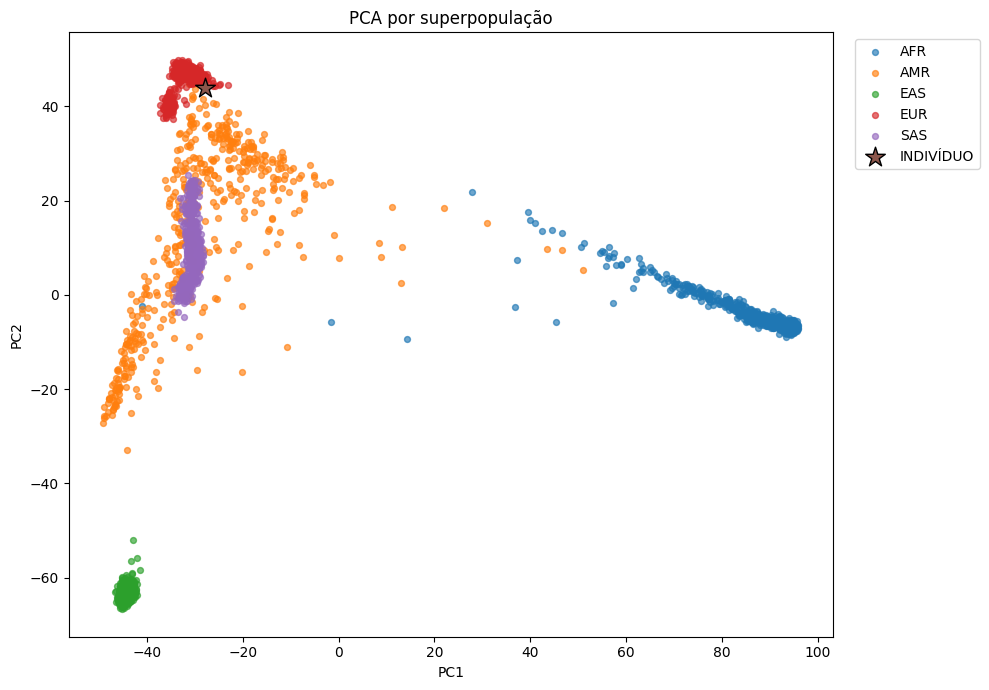

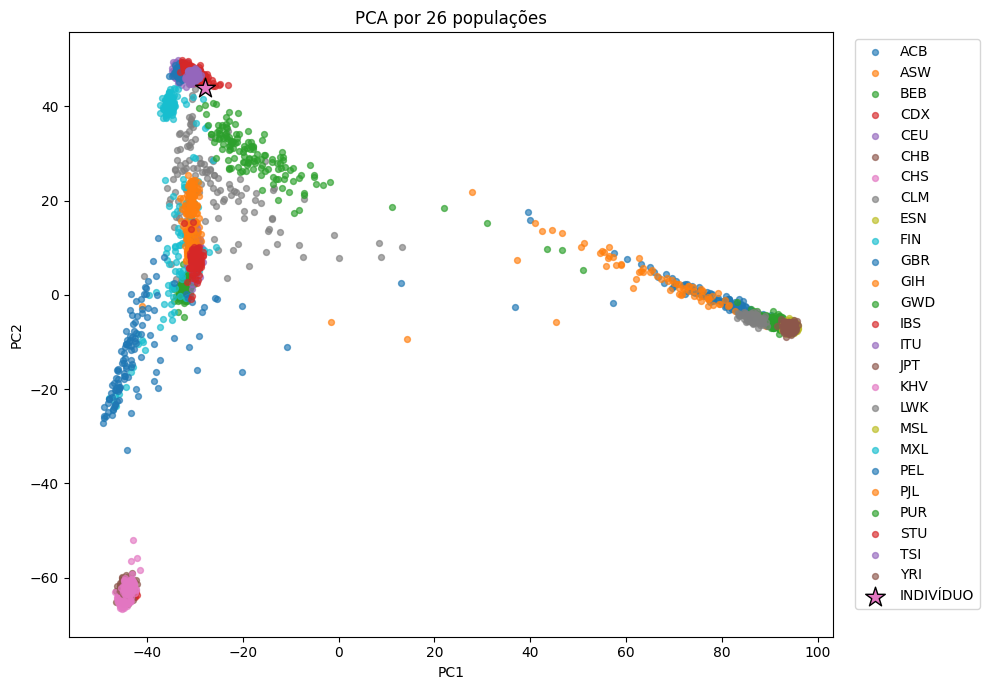

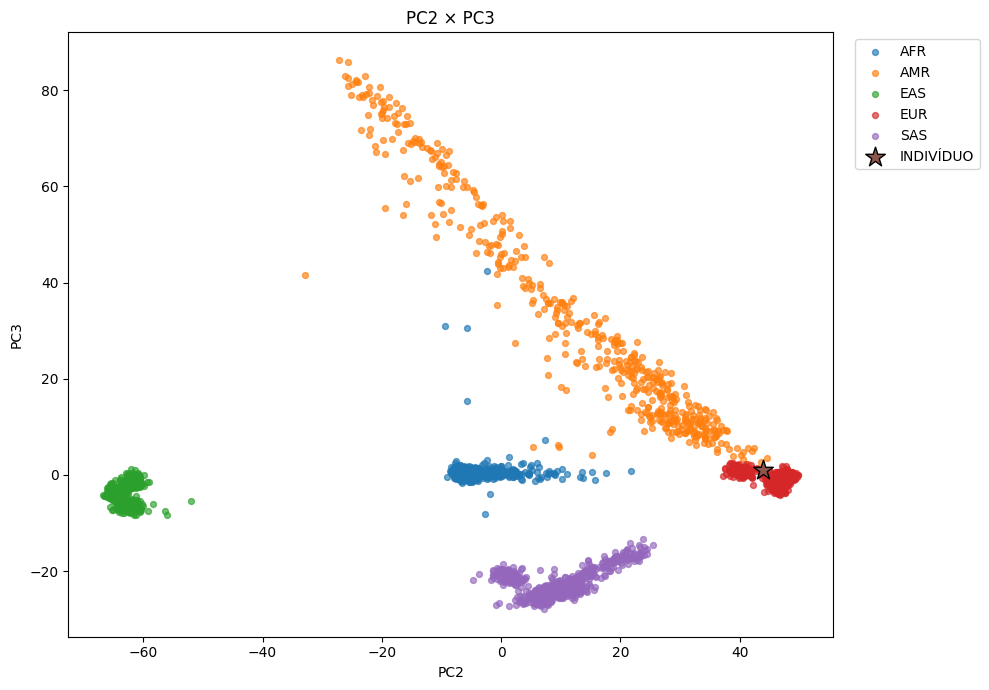

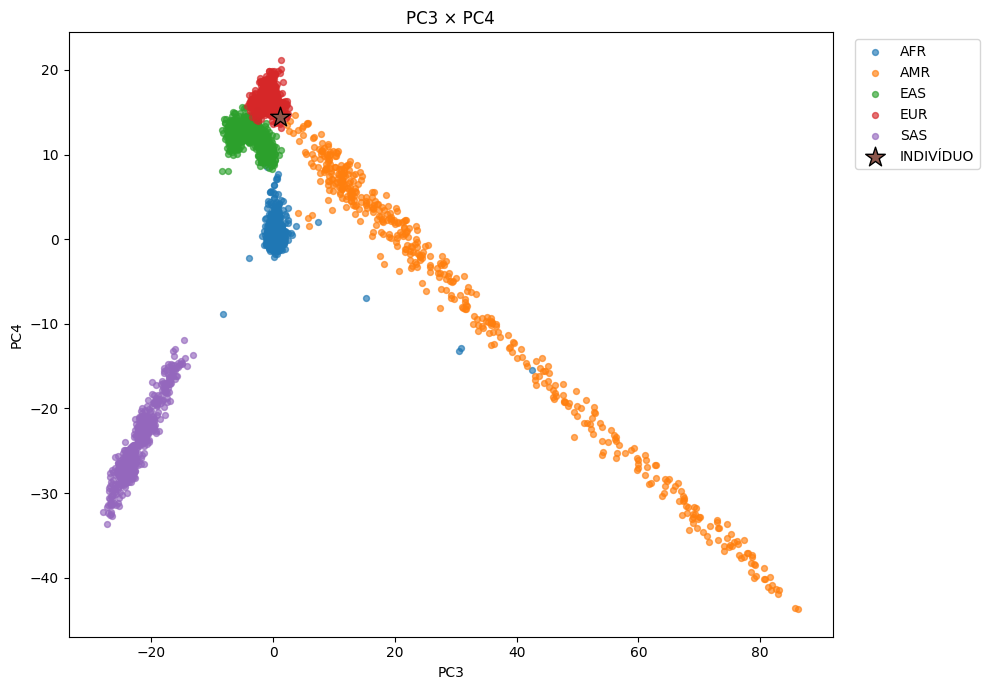

,0
IBS,6.774247
TSI,6.949428
GBR,10.823845
CEU,12.064230
PUR,22.872128
FIN,27.721777
CLM,33.088821
PJL,50.593987
GIH,54.672432
MXL,58.852592


,0
IBS,5.371214e-01
TSI,4.508087e-01
GBR,9.361695e-03
CEU,2.708084e-03
PUR,5.480899e-08
FIN,4.292159e-10
CLM,2.003540e-12
PJL,5.004969e-20
GIH,8.475299e-22
MXL,1.296386e-23


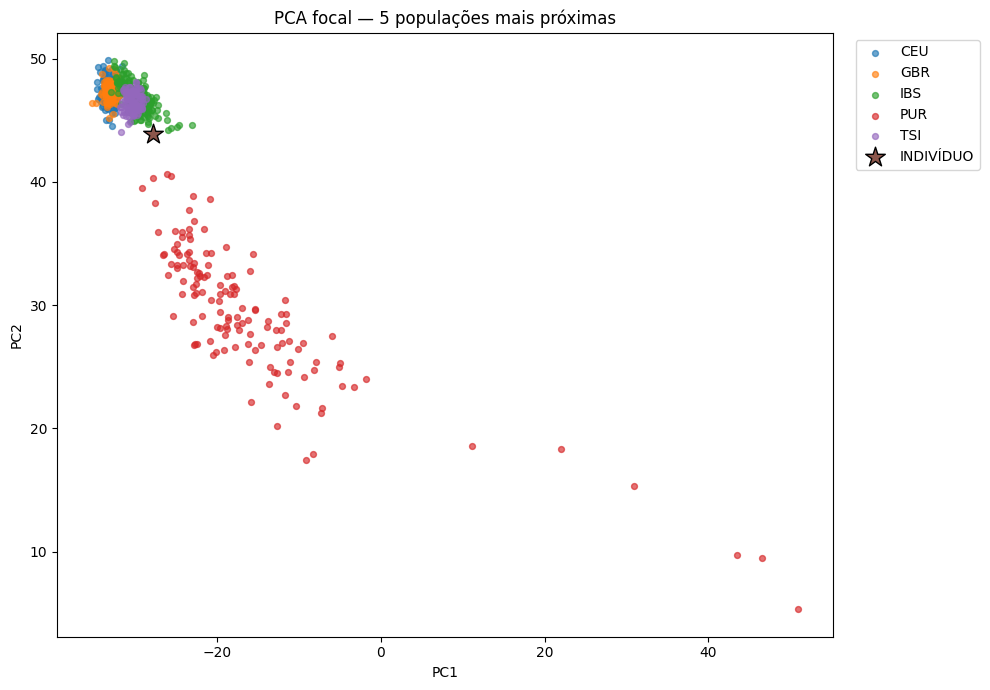

In [66]:
X_ref_int=read_final_positions(selected_positions); x_ind_int=X_individuo[selected_positions]; means=2.0*freq_alt[selected_positions]
X_ref=impute_matrix(X_ref_int,means); X_ind=impute_vector(x_ind_int,means)
NCOMP=10; pca=PCA(n_components=NCOMP,svd_solver='randomized',random_state=RANDOM_STATE); ref_coords=pca.fit_transform(X_ref); ind_coords=pca.transform(X_ind.reshape(1,-1))
pcs=[f'PC{i}' for i in range(1,NCOMP+1)]; pca_df=pd.DataFrame(ref_coords,columns=pcs); pca_df['sample']=metadata["sample"].to_numpy(); pca_df['population']=metadata.population.to_numpy(); pca_df['superpopulation']=metadata.superpopulation.to_numpy()
for i,v in enumerate(pca.explained_variance_ratio_,1): print(f'PC{i}: {100*v:.3f}%')

def plot_pca(group,pcx='PC1',pcy='PC2',only=None,title=None):
    plt.figure(figsize=(10,7)); d=pca_df if only is None else pca_df[pca_df[group].isin(only)]
    for g in sorted(d[group].unique()):
        z=d[d[group]==g]; plt.scatter(z[pcx],z[pcy],s=18,alpha=.65,label=g)
    ix=int(pcx[2:])-1; iy=int(pcy[2:])-1; plt.scatter(ind_coords[0,ix],ind_coords[0,iy],s=220,marker='*',edgecolor='black',label='INDIVÍDUO')
    plt.xlabel(pcx); plt.ylabel(pcy); plt.title(title or f'{pcx} × {pcy} por {group}'); plt.legend(bbox_to_anchor=(1.02,1),loc='upper left'); plt.tight_layout(); plt.show()

plot_pca('superpopulation','PC1','PC2','' if False else None,'PCA por superpopulação')
plot_pca('population','PC1','PC2',None,'PCA por 26 populações')
plot_pca('superpopulation','PC2','PC3',None,'PC2 × PC3')
plot_pca('superpopulation','PC3','PC4',None,'PC3 × PC4')

cent=pca_df.groupby('population')[pcs].mean(); ind=ind_coords[0]; ranking=pd.Series({p:np.linalg.norm(ind-cent.loc[p].to_numpy()) for p in cent.index}).sort_values(); display(ranking.head(10))
T=1.0; sc=np.exp(-ranking.to_numpy()/T); sc/=sc.sum(); similaridade=pd.Series(sc,index=ranking.index).sort_values(ascending=False); display(similaridade.head(10))
plot_pca('population','PC1','PC2',ranking.head(5).index.tolist(),'PCA focal — 5 populações mais próximas')

Este bloco implementa a classificação de ancestralidade usando k-Nearest Neighbors (k-NN), tanto de forma direta quanto hierárquica. Ele divide os dados de referência em conjuntos de treinamento e teste, aplica PCA aos dados de treinamento e, em seguida, treina modelos k-NN para prever a população e superpopulação. São exibidas as acurácias de classificação para as 26 populações e superpopulações, além da predição da ancestralidade do indivíduo pelo modelo k-NN.

In [67]:
# k-NN direto e hierárquico
y_pop=metadata.population.to_numpy(); y_super=metadata.superpopulation.to_numpy(); ids=np.arange(N)
tr,te=train_test_split(ids,test_size=.20,stratify=y_pop,random_state=RANDOM_STATE)
pclf=PCA(n_components=10,svd_solver='randomized',random_state=RANDOM_STATE); trpc=pclf.fit_transform(X_ref[tr]); tepc=pclf.transform(X_ref[te]); ipc=pclf.transform(X_ind.reshape(1,-1))
knn=KNeighborsClassifier(n_neighbors=15,weights='distance').fit(trpc,y_pop[tr]); pred=knn.predict(tepc)
print('Accuracy 26 populações=',accuracy_score(y_pop[te],pred)); print(classification_report(y_pop[te],pred)); pred_ind=knn.predict(ipc)[0]; print('Indivíduo (direto)=',pred_ind)
proba_ind=pd.Series(knn.predict_proba(ipc)[0],index=knn.classes_).sort_values(ascending=False); display(proba_ind.head(10))
ks=KNeighborsClassifier(n_neighbors=15,weights='distance').fit(trpc,y_super[tr]); pred_s=ks.predict(tepc); ind_s=ks.predict(ipc)[0]
pred_h=np.empty(len(te),dtype=object)
for s in sorted(set(y_super[tr])):
    mt=y_super[tr]==s; me=pred_s==s
    if not me.any(): continue
    sub=KNeighborsClassifier(n_neighbors=min(15,int(mt.sum())),weights='distance').fit(trpc[mt],y_pop[tr][mt]); pred_h[me]=sub.predict(tepc[me])
print('Accuracy hierárquica=',accuracy_score(y_pop[te],pred_h)); print('Accuracy superpop=',accuracy_score(y_super[te],pred_s))
mt=y_super[tr]==ind_s; sub=KNeighborsClassifier(n_neighbors=min(15,int(mt.sum())),weights='distance').fit(trpc[mt],y_pop[tr][mt]); ind_p=sub.predict(ipc)[0]; print('Indivíduo (hierárquico)=',ind_s,'→',ind_p)

Accuracy 26 populações= 0.8081123244929798
              precision    recall  f1-score   support

         ACB       0.86      0.83      0.84        23
         ASW       0.75      0.80      0.77        15
         BEB       0.96      0.96      0.96        26
         CDX       1.00      0.21      0.35        19
         CEU       0.90      0.25      0.39        36
         CHB       0.86      0.57      0.69        21
         CHS       0.78      0.94      0.85        33
         CLM       0.80      0.92      0.86        26
         ESN       0.90      0.30      0.45        30
         FIN       1.00      0.95      0.97        20
         GBR       0.40      1.00      0.57        18
         GIH       1.00      0.62      0.76        21
         GWD       1.00      0.94      0.97        36
         IBS       0.94      0.97      0.95        31
         ITU       0.69      0.43      0.53        21
         JPT       1.00      1.00      1.00        21
         KHV       0.62      1.00     

,0
IBS,0.738483
TSI,0.196250
PUR,0.065267
BEB,0.000000
CEU,0.000000
CHB,0.000000
CHS,0.000000
CDX,0.000000
ACB,0.000000
ASW,0.000000


Accuracy hierárquica= 0.8081123244929798
Accuracy superpop= 1.0
Indivíduo (hierárquico)= EUR → IBS


Este bloco implementa um modelo simplificado de mistura para estimar a proporção de ancestralidade do indivíduo em relação às populações de referência. Ele utiliza as frequências alélicas das variantes selecionadas e resolve um problema de otimização para encontrar os pesos (contribuições) de cada população que melhor explicam o genótipo do indivíduo. Os resultados são exibidos como porcentagens de contribuição para cada população e superpopulação, acompanhados de gráficos de barras para visualização.

Convergiu? True Optimization terminated successfully
SNPs usados: 570874


,%
IBS,35.711
TSI,22.727
CEU,12.170
PUR,8.884
GBR,8.732
CLM,7.829
FIN,3.575
GWD,0.187
LWK,0.186
BEB,0.000


,%
superpop,
EUR,82.915
AMR,16.712
AFR,0.373
SAS,0.000
EAS,0.000


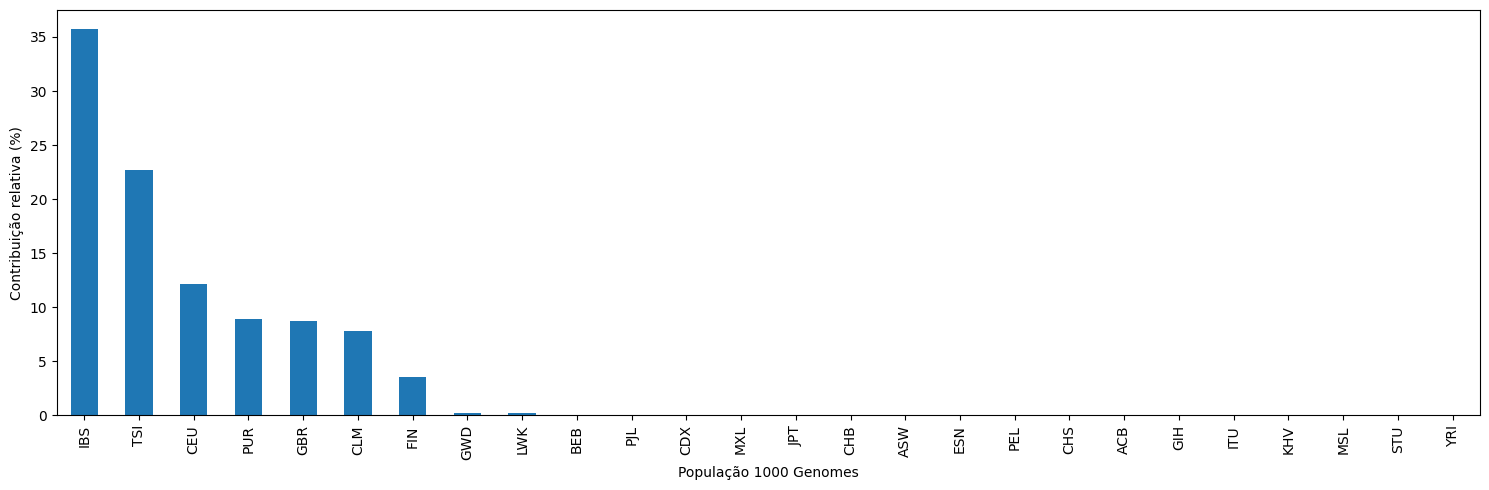

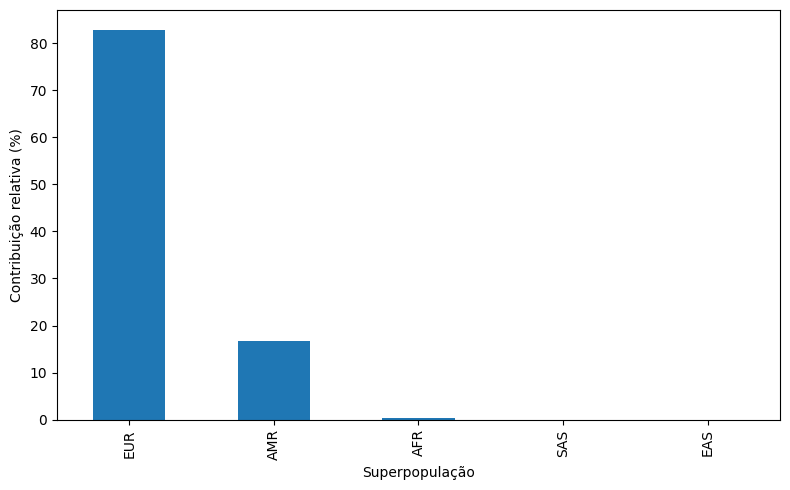

In [68]:
# Modelo simplificado de mistura por frequências
# Usa todos os SNPs válidos após QC

mix_positions = qc_positions.copy()

P = freq_pop[mix_positions, :].astype(float)
g = X_individuo[mix_positions].astype(float)

ok = (g >= 0) & np.isfinite(P).all(axis=1)

Pm = P[ok]
gm = g[ok]

K = Pm.shape[1]

def objective(w):
    esperado = 2.0 * Pm.dot(w)
    return np.mean((gm - esperado) ** 2)

w0 = np.ones(K) / K
bounds = [(0, 1)] * K

cons = {
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
}

opt = minimize(
    objective,
    w0,
    method='SLSQP',
    bounds=bounds,
    constraints=cons,
    options={
        'maxiter': 1000,
        'ftol': 1e-10
    }
)

print('Convergiu?', opt.success, opt.message)
print('SNPs usados:', len(gm))

# Mantemos o nome "pesos" porque as células posteriores usam essa variável
pesos = pd.Series(
    opt.x,
    index=pops
).sort_values(ascending=False)

display(
    (100 * pesos)
    .round(3)
    .to_frame('%')
)

# Agregação por superpopulação
respop = pesos.to_frame('score')
respop['superpop'] = respop.index.map(pop_to_super)

ressuper = (
    respop
    .groupby('superpop')['score']
    .sum()
    .sort_values(ascending=False)
)

display(
    (100 * ressuper)
    .round(3)
    .to_frame('%')
)

# Gráfico das 26 populações
plt.figure(figsize=(15, 5))
(100 * pesos).plot(kind='bar')
plt.ylabel('Contribuição relativa (%)')
plt.xlabel('População 1000 Genomes')
plt.tight_layout()
plt.show()

# Gráfico das superpopulações
plt.figure(figsize=(8, 5))
(100 * ressuper).plot(kind='bar')
plt.ylabel('Contribuição relativa (%)')
plt.xlabel('Superpopulação')
plt.tight_layout()
plt.show()

Este bloco consolida e exibe os resultados finais da análise genômica populacional. Ele resume o número de SNPs em cada etapa do pipeline (original, harmonizado, após QC, após LD pruning e final), e apresenta as contribuições de superpopulações e populações calculadas pelo modelo de mistura. Também mostra as populações mais próximas pelo ranking de centroides da PCA e as predições de ancestralidade pelos classificadores k-NN direto e hierárquico.

In [69]:
# Saída final
print('='*45); print('ANÁLISE GENÔMICA POPULACIONAL'); print('='*45)
print(f'SNPs no arquivo: {len(ind_raw):,}')
print(f'SNPs encontrados no mapa: {int(tmp.GT.notna().sum()):,}')
print(f'SNPs após harmonização: {int((X_individuo>=0).sum()):,}')
print(f'SNPs após QC: {len(qc_positions):,}')
print(f'SNPs após LD pruning: {len(ld_positions):,}')
print(f'SNPs usados em PCA/k-NN: {len(selected_positions):,}')
print(f'SNPs usados no modelo de mistura: {len(gm):,}')
print('SUPERPOPULAÇÕES — mistura'); [print(f'{k:4s} {100*v:7.2f}%') for k,v in ressuper.items()]
print('POPULAÇÕES — mistura'); [print(f'{k:4s} {100*v:7.2f}%') for k,v in pesos.head(10).items()]
print('PCA — centroides'); [print(f'{k:4s} d={v:.4f}') for k,v in ranking.head(5).items()]
print('k-NN direto:',pred_ind); print('k-NN hierárquico:',ind_s,'→',ind_p)

ANÁLISE GENÔMICA POPULACIONAL
SNPs no arquivo: 654,027
SNPs encontrados no mapa: 572,011
SNPs após harmonização: 570,874
SNPs após QC: 570,874
SNPs após LD pruning: 327,824
SNPs usados em PCA/k-NN: 50,000
SNPs usados no modelo de mistura: 570,874
SUPERPOPULAÇÕES — mistura
EUR    82.91%
AMR    16.71%
AFR     0.37%
SAS     0.00%
EAS     0.00%
POPULAÇÕES — mistura
IBS    35.71%
TSI    22.73%
CEU    12.17%
PUR     8.88%
GBR     8.73%
CLM     7.83%
FIN     3.57%
GWD     0.19%
LWK     0.19%
BEB     0.00%
PCA — centroides
IBS  d=6.7742
TSI  d=6.9494
GBR  d=10.8238
CEU  d=12.0642
PUR  d=22.8721
k-NN direto: IBS
k-NN hierárquico: EUR → IBS


Este bloco realiza uma validação interna do modelo usando validação cruzada estratificada de 5 *folds*. Ele treina um classificador k-NN em cada *fold* para prever a população e calcula métricas como Top-1 (acurácia da primeira predição), Top-3 (acurácia se a população real estiver entre as três primeiras predições) e acurácia da superpopulação. Uma matriz de confusão também é gerada para visualizar o desempenho do classificador em todas as populações.

fold 1
fold 2
fold 3
fold 4
fold 5
Top-1= 0.8154278575890068 Top-3= 0.9887570268582137 Superpop= 0.9968769519050593


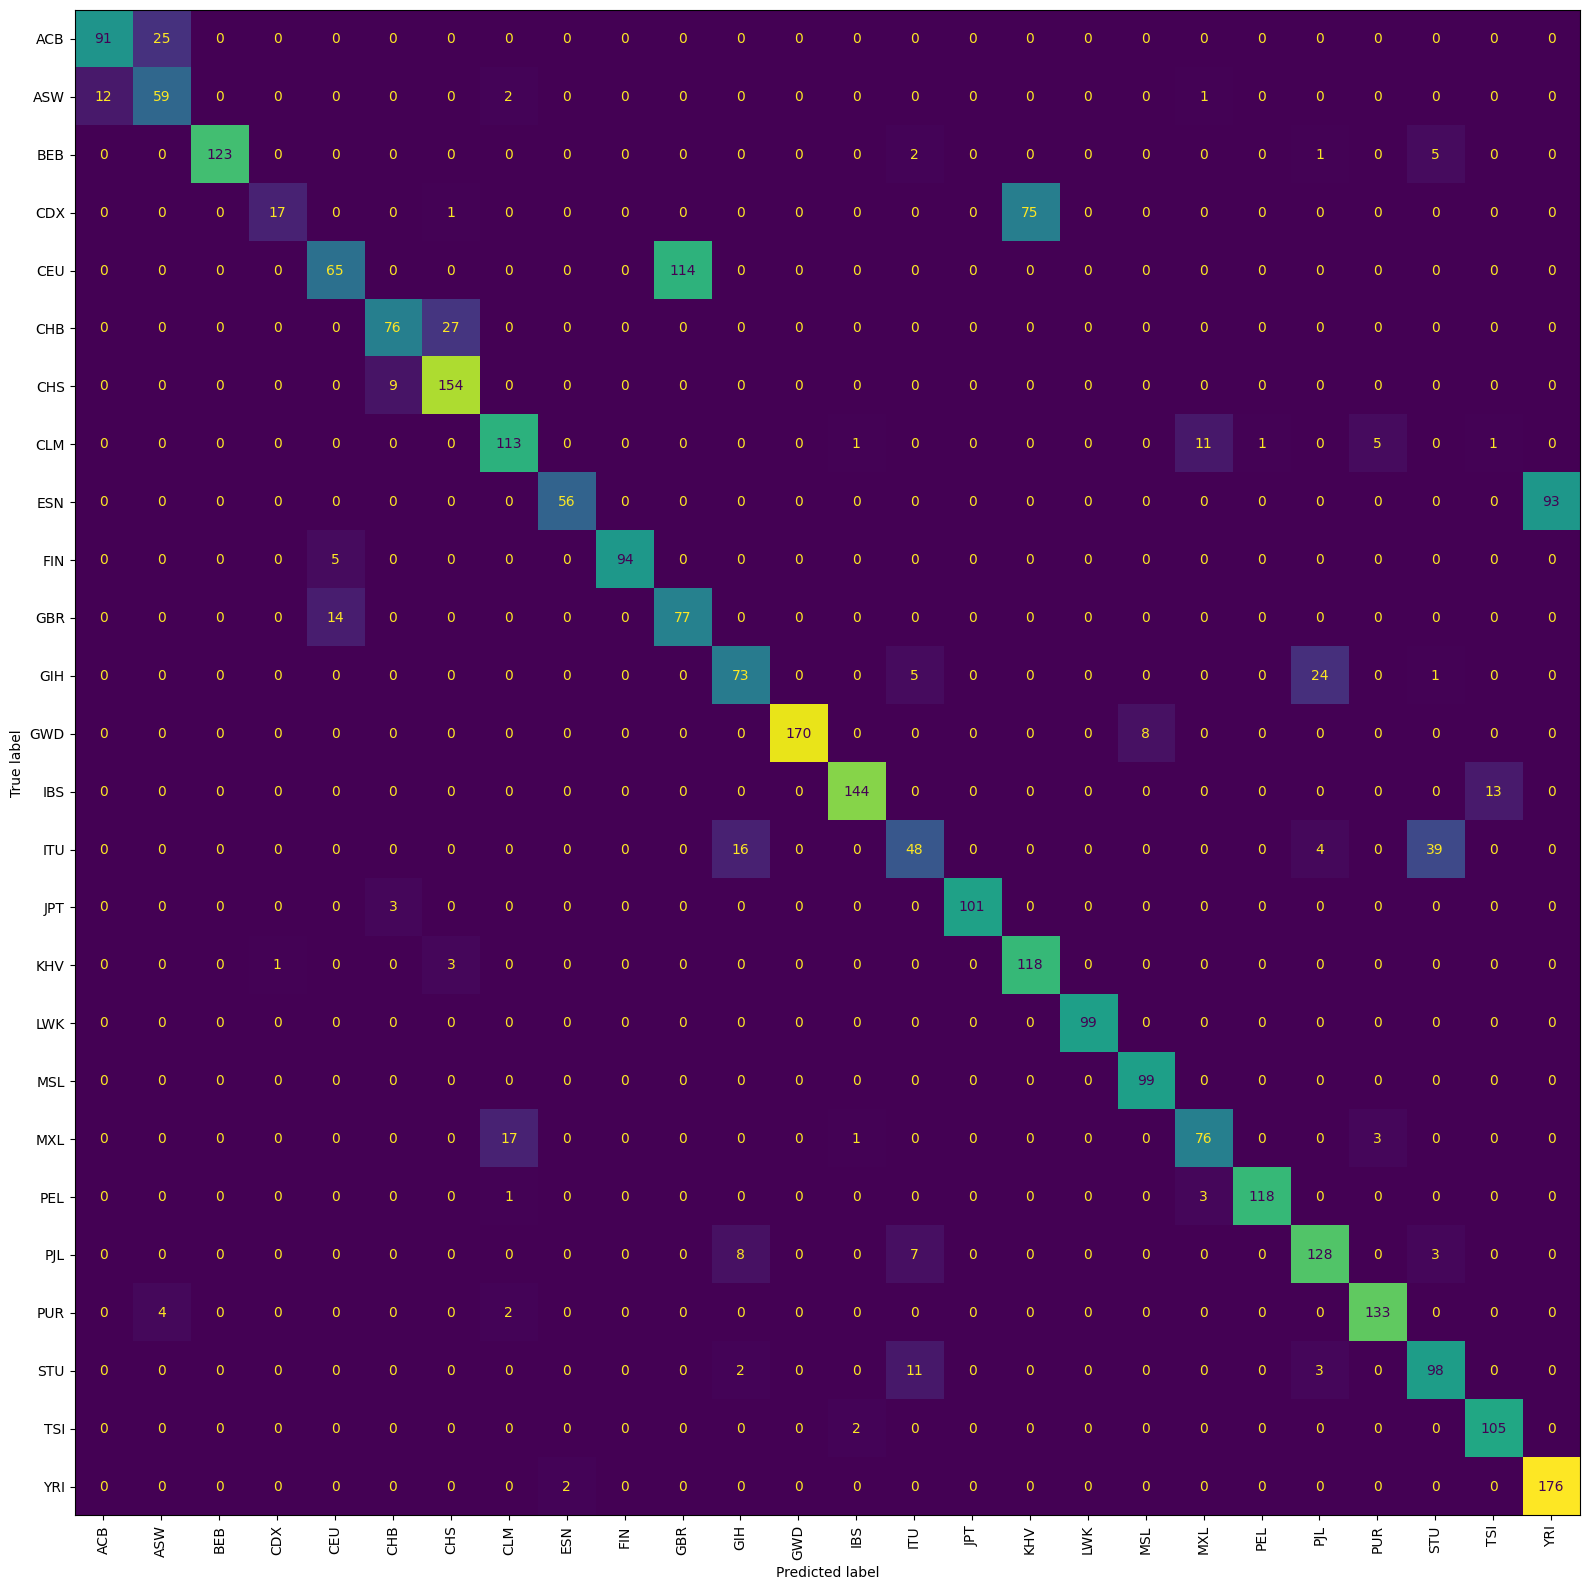

In [70]:
# Validação interna 5-fold: Top-1, Top-3, superpop e matriz de confusão.
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE); classes=np.array(sorted(np.unique(y_pop))); c2i={c:i for i,c in enumerate(classes)}; pred_oof=np.empty(N,dtype=object); proba=np.zeros((N,len(classes)))
for fold,(tr,te) in enumerate(skf.split(X_ref,y_pop),1):
    p=PCA(n_components=10,svd_solver='randomized',random_state=RANDOM_STATE); a=p.fit_transform(X_ref[tr]); b=p.transform(X_ref[te]); c=KNeighborsClassifier(n_neighbors=15,weights='distance').fit(a,y_pop[tr]); pred_oof[te]=c.predict(b); pr=c.predict_proba(b)
    for j,cl in enumerate(c.classes_): proba[te,c2i[cl]]=pr[:,j]
    print('fold',fold)
top1=accuracy_score(y_pop,pred_oof); top3labels=classes[np.argsort(proba,axis=1)[:,-3:]]; top3=np.mean([y_pop[i] in top3labels[i] for i in range(N)]); trueS=np.array([pop_to_super[p] for p in y_pop]); predS=np.array([pop_to_super[p] for p in pred_oof]); accS=accuracy_score(trueS,predS)
print('Top-1=',top1,'Top-3=',top3,'Superpop=',accS)
cm=confusion_matrix(y_pop,pred_oof,labels=classes); fig,ax=plt.subplots(figsize=(16,16)); ConfusionMatrixDisplay(cm,display_labels=classes).plot(ax=ax,xticks_rotation=90,colorbar=False,values_format='d'); plt.tight_layout(); plt.show()

Este bloco compara o impacto do número de SNPs utilizados na análise nos resultados da PCA e do classificador k-NN. A função `compare_n` é definida para executar o pipeline com diferentes quantidades de SNPs (1k, 5k, 10k, 20k, 50k) e retorna métricas como a variância explicada pela PCA, a população mais próxima pela PCA e a acurácia do k-NN. Os resultados são apresentados em um DataFrame para fácil comparação.

In [56]:
# Comparação 1k / 5k / 10k / 20k / 50k SNPs
def compare_n(n):
    pos=ranked_ld[:min(n,len(ranked_ld))]; Xi=read_final_positions(pos); xi=X_individuo[pos]; mm=2*freq_alt[pos]; X=impute_matrix(Xi,mm); x=impute_vector(xi,mm)
    p=PCA(n_components=10,svd_solver='randomized',random_state=RANDOM_STATE); rc=p.fit_transform(X); ic=p.transform(x.reshape(1,-1))[0]; df=pd.DataFrame(rc,columns=pcs); df['population']=y_pop; cc=df.groupby('population')[pcs].mean(); ds=pd.Series({q:np.linalg.norm(ic-cc.loc[q].to_numpy()) for q in cc.index}).sort_values()
    tr,te=train_test_split(np.arange(N),test_size=.2,stratify=y_pop,random_state=RANDOM_STATE); pp=PCA(n_components=10,svd_solver='randomized',random_state=RANDOM_STATE); aa=pp.fit_transform(X[tr]); bb=pp.transform(X[te]); clf=KNeighborsClassifier(n_neighbors=15,weights='distance').fit(aa,y_pop[tr]); ac=accuracy_score(y_pop[te],clf.predict(bb))
    return {'n_snps':len(pos),'var_10pcs_pct':100*p.explained_variance_ratio_.sum(),'pop_mais_proxima_pca':ds.index[0],'distancia':ds.iloc[0],'knn_accuracy':ac}
rows=[]
for n in [1000,5000,10000,20000,50000]:
    print('Rodando',n); rows.append(compare_n(n))
comparacao_df=pd.DataFrame(rows); display(comparacao_df)

Rodando 1000
Rodando 5000
Rodando 10000
Rodando 20000
Rodando 50000


,n_snps,var_10pcs_pct,pop_mais_proxima_pca,distancia,knn_accuracy
0,1000,49.609421,TSI,2.135980,0.569423
1,5000,39.296635,IBS,2.444801,0.750390
2,10000,34.110580,IBS,3.309436,0.776911
3,20000,28.404089,IBS,3.774140,0.790952
4,50000,20.920162,IBS,6.774247,0.808112


## Interpretação final

No relatório, use os **resultados reais** impressos acima e discuta: PCA (incluindo PC2×PC3 e PC3×PC4), ranking de centroides, classificador direto e hierárquico, Top-1/Top-3/superpopulação, pesos do modelo de mistura, estabilidade com 50k/20k/10k/5k/1k SNPs e efeito do LD pruning.

Não trate score de afinidade, probabilidade de classe ou peso do modelo didático como porcentagem literal de nacionalidade. Discuta composição limitada da referência, miscigenação, LD, frequências estimadas em amostras finitas, populações geneticamente semelhantes, escolha de SNPs, deriva e incerteza estatística.

Para encerrar: `pgen.close()`.

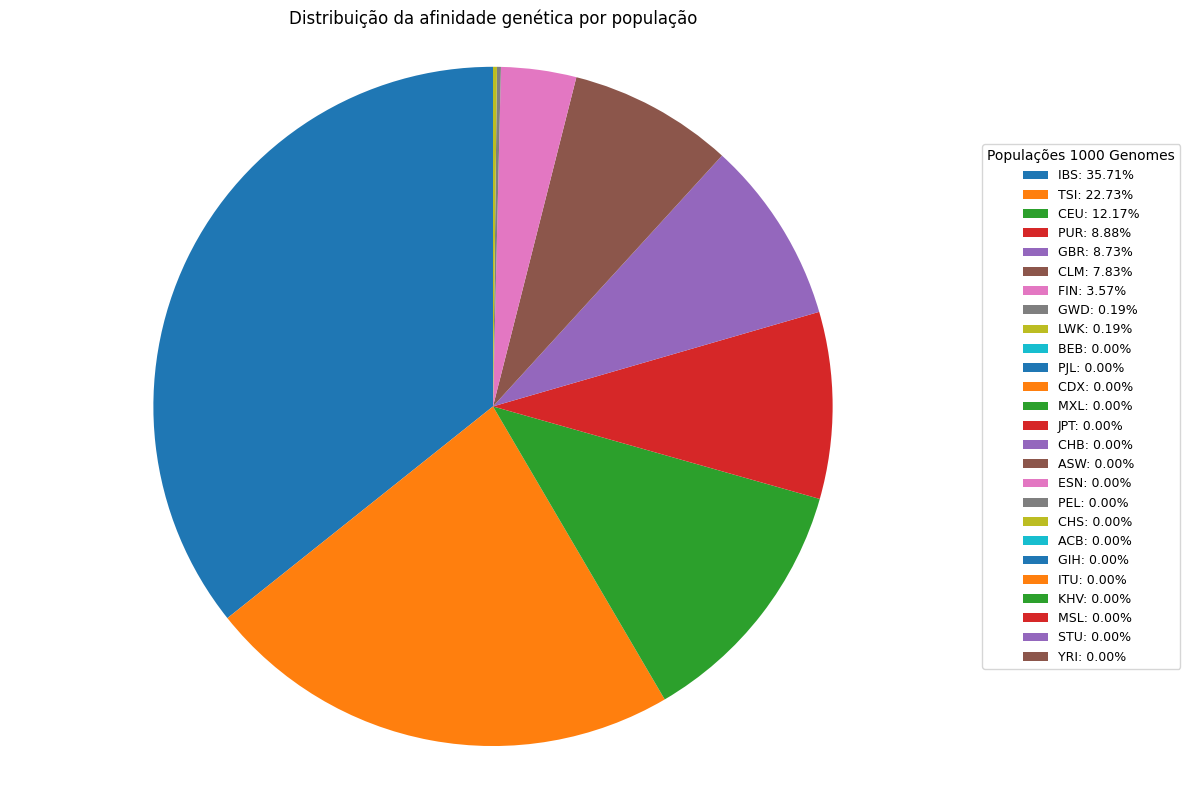

In [71]:
# Gráfico de pizza — porcentagem por população

resultado_pct = (pesos * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

wedges, _ = ax.pie(
    resultado_pct.values,
    startangle=90
)

# Legenda com população e porcentagem
legenda = [
    f'{pop}: {valor:.2f}%'
    for pop, valor in resultado_pct.items()
]

ax.legend(
    wedges,
    legenda,
    title='Populações 1000 Genomes',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=9
)

ax.set_title(
    'Distribuição da afinidade genética por população'
)

ax.axis('equal')

plt.tight_layout()
plt.show()